# 04 · Full hypothesis library and test ratios on a real point

**Objective:** Apply the complete Table I library (plus per-epoch step search) to a real EGMS point, and inspect all test ratios, not just the winner.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms, temperature

In [2]:
ds = egms.load_cached(
    "../data/processed/alicante_marina_metadata.parquet",
    "../data/processed/alicante_marina_displacements.parquet",
)
temp = temperature.load_daily_temperature("../data/processed/alicante_daily_temperature.csv")

# Same point as notebooks 01-02: H0 rejected there, seasonal alone barely helped,
# residual looked like a one-off dip around year 2 rather than an annual cycle.
pid = ds.metadata.loc[ds.metadata["mean_velocity"].abs().idxmax(), "pid"]
dates, t, y = egms.point_series(ds, pid)
delta_temp = temperature.delta_temp_for_dates(temp, dates)

print(f"point {pid}: {len(t)} epochs, {t[-1]:.2f} years, "
      f"delta_temp range [{delta_temp.min():.1f}, {delta_temp.max():.1f}] K")

point 48GPP2M1IM: 210 epochs, 4.98 years, delta_temp range [-1.7, 20.8] K


In [3]:
A0 = library.design_matrix_h0(t)
sigma = 3.0
Qyy = (sigma ** 2) * np.eye(len(t))
Qyy_inv = np.linalg.inv(Qyy)
h0_fit = testing.gls_fit(y, A0, Qyy_inv)

alpha0 = 1 / (2 * len(t))
gamma0 = 0.5
q0 = len(t) - A0.shape[1]
T0 = testing.omt_statistic(h0_fit.e_hat, Qyy_inv)
K = stats.chi2.ppf(1 - alpha0, q0)
print(f"T0={T0:.1f}, K={K:.1f} -> {'REJECTED' if T0 > K else 'sustained'}")

library_hyps = hypotheses.table_i_hypotheses(t, delta_temp, beta_grid=[0.1, 0.25, 0.5, 1.0])
print(f"{len(library_hyps)} candidate hypotheses")

lambda0 = testing.noncentrality_from_power(gamma0, alpha0, q=1)
precomputed = [
    dia.precompute_hypothesis_class(h, Qyy_inv, h0_fit.q_ehat_ehat, lambda0, gamma0) for h in library_hyps
]

T0=443.9, K=271.4 -> REJECTED
1264 candidate hypotheses


In [4]:
result = dia.run_dia(y, A0, Qyy, precomputed, alpha0)

ranked = sorted(result.all_ratios.items(), key=lambda kv: kv[1], reverse=True)
print("top 10 hypotheses by test ratio:")
for name, ratio in ranked[:10]:
    print(f"  {ratio:6.2f}  {name}")
print()
print(f"winner: {result.best_hypothesis.name}  (ratio={result.best_ratio:.2f})")

top 10 hypotheses by test ratio:
   11.34  H6_thermal+step@112
   11.09  H6_thermal+step@113
   10.97  H6_thermal+step@114
   10.32  H6_thermal+step@111
   10.27  H7_thermal+seasonal+step@112
   10.01  H6_thermal+step@115
   10.00  H7_thermal+seasonal+step@113
    9.85  H7_thermal+seasonal+step@114
    9.59  H5_exp+step@78(beta=0.5)
    9.54  H5_exp+step@78(beta=1)

winner: H6_thermal+step@112  (ratio=11.34)


step epoch 112 -> 2021-11-17  (t=1.87 yr)
v_hat=-6.41 mm/yr, eta_hat=-0.149 mm/K, Delta_hat=-8.53 mm
RSS: H0=3995  winner=2949


Text(0.5, 1.0, 'point 48GPP2M1IM')

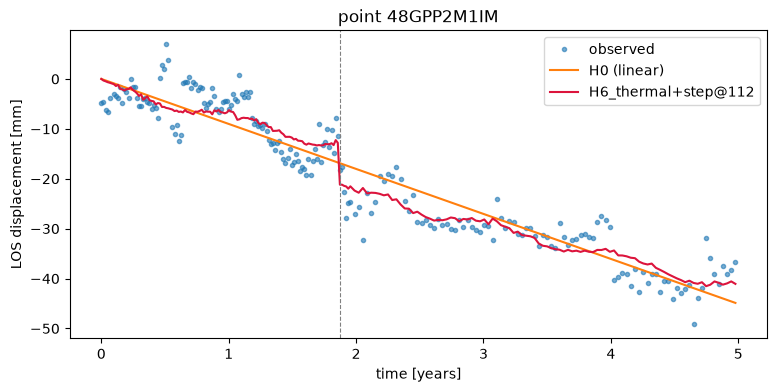

In [5]:
step_epoch = int(result.best_hypothesis.name.rsplit("@", 1)[-1])
print(f"step epoch {step_epoch} -> {dates[step_epoch].date()}  (t={t[step_epoch]:.2f} yr)")

v_hat, eta_hat, delta_hat = result.best_fit.x_hat
print(f"v_hat={v_hat:.2f} mm/yr, eta_hat={eta_hat:.3f} mm/K, Delta_hat={delta_hat:.2f} mm")
print(f"RSS: H0={np.sum(h0_fit.e_hat**2):.0f}  winner={np.sum(result.best_fit.e_hat**2):.0f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, ".", label="observed", alpha=0.6)
ax.plot(t, h0_fit.y_hat, "-", label="H0 (linear)")
ax.plot(t, result.best_fit.y_hat, "-", color="crimson", label=result.best_hypothesis.name)
ax.axvline(t[step_epoch], color="gray", ls="--", lw=0.8)
ax.set_xlabel("time [years]"); ax.set_ylabel("LOS displacement [mm]"); ax.legend()
ax.set_title(f"point {pid}")

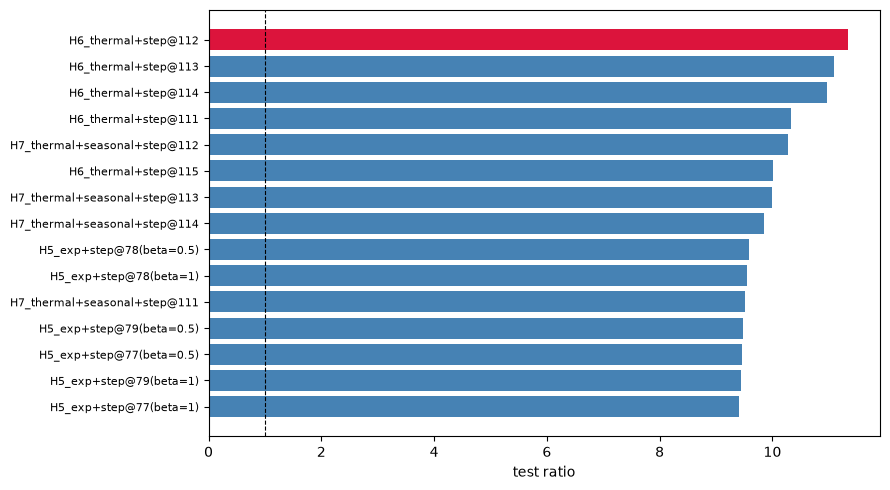

In [6]:
# Bar plot of the top candidates: how much better is the winner than the runners-up?
top_n = 15
names, ratios = zip(*ranked[:top_n])
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if n == result.best_hypothesis.name else "steelblue" for n in names]
ax.barh(range(top_n), ratios, color=colors)
ax.set_yticks(range(top_n)); ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis()
ax.axvline(1.0, color="k", lw=0.8, ls="--")
ax.set_xlabel("test ratio")
plt.tight_layout()